# Telco Customer Churn Prediction with Logistic Regression


## Complete end-to-end machine learning workflow

This notebook loads `Telco_Customer_Churn.csv`, cleans the data, engineers features, encodes categorical values, scales numeric values, handles class imbalance with SMOTE, trains logistic regression, evaluates all major classification metrics, validates with cross-validation, and saves the complete fitted pipeline as a `.pkl` file.


In [1]:
# 1. Import libraries
import os
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
)
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
pd.set_option("display.max_columns", 100)
sns.set_theme(style="whitegrid")


In [2]:
# 2. Load the Telco Customer Churn dataset
file_path = r"D:\AI_Training\Telco_Customer_Churn.csv"
df = pd.read_csv(file_path)

print(f"Dataset loaded from: {file_path}")
print(f"Rows: {df.shape[0]:,} | Columns: {df.shape[1]}")
df.head()


Dataset loaded from: D:\AI_Training\Telco_Customer_Churn.csv
Rows: 7,043 | Columns: 21


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [102]:
# 3. Initial data inspection
print("Column names:")
print(df.columns.tolist())
print("\nData types and non-null counts:")
df.info()
print("\nDuplicate rows:", df.duplicated().sum())
print("\nTarget distribution:")
print(df["Churn"].value_counts(dropna=False))
print("\nTarget percentage:")
print((df["Churn"].value_counts(normalize=True, dropna=False) * 100).round(2))


Column names:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Data types and non-null counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   

In [3]:
# 4. Basic cleaning before splitting the data
# Remove accidental spaces from column names and string values.
df.columns = df.columns.str.strip()
object_columns = df.select_dtypes(include="object").columns
for column in object_columns:
    df[column] = df[column].str.strip()

# Convert TotalCharges to numeric; blank strings become missing values.
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Remove exact duplicate records and the identifier column.
df = df.drop_duplicates().reset_index(drop=True)
df = df.drop(columns=["customerID"])

print("Missing values after basic cleaning:")
print(df.isna().sum().sort_values(ascending=False).head(10))
print("\nShape after cleaning:", df.shape)


Missing values after basic cleaning:
TotalCharges      11
gender             0
Partner            0
SeniorCitizen      0
Dependents         0
tenure             0
MultipleLines      0
PhoneService       0
OnlineSecurity     0
OnlineBackup       0
dtype: int64

Shape after cleaning: (7043, 20)


In [4]:
# 5. Feature engineering
# These features are created before the sklearn preprocessing pipeline.
service_columns = [
    "PhoneService",
    "MultipleLines",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
]

# Count active services; unavailable services are encoded as zero.
service_flags = df[service_columns].apply(
    lambda column: (~column.isin(["No", "No internet service", "No phone service"])).astype(int)
)
df["TotalServices"] = service_flags.sum(axis=1)
df["HasInternetService"] = (~df["InternetService"].eq("No")).astype(int)
df["MonthlyChargesPerTenure"] = df["MonthlyCharges"] / df["tenure"].replace(0, np.nan)

print(df[["TotalServices", "HasInternetService", "MonthlyChargesPerTenure"]].describe())


       TotalServices  HasInternetService  MonthlyChargesPerTenure
count    7043.000000         7043.000000              7032.000000
mean        3.362914            0.783331                 8.620087
std         2.062031            0.412004                16.352057
min         0.000000            0.000000                 0.268056
25%         1.000000            1.000000                 1.277708
50%         3.000000            1.000000                 2.147286
75%         5.000000            1.000000                 6.611218
max         8.000000            1.000000               102.450000


## 6. Encoding theory: converting categorical data into numbers

Most machine-learning algorithms cannot calculate directly with values such as `Yes`, `No`, `Month-to-month`, or `Fiber optic`. Encoding converts categories into numerical representations.

**Encoding methods used in this lesson:**

1. **Mapping:** best for binary categories with a natural meaning, such as `Yes -> 1` and `No -> 0`.
2. **List comprehension:** a Python technique for applying a custom rule across values. It is useful for simple binary transformations, but it must be checked carefully for unexpected categories.
3. **Label encoding:** assigns an integer to each category. It is suitable for the target or truly ordered categories. It can create a false order when used for nominal predictors.
4. **One-hot encoding:** creates one binary column per category. This is the safest general method for nominal predictors such as contract and payment method.

For the production model, the final categorical preprocessing uses `OneHotEncoder(handle_unknown="ignore")` inside a scikit-learn pipeline. The examples below are educational demonstrations and do not mutate the model data.


In [123]:
# 7. Identify object-type columns and inspect their categories
object_feature_columns = df.select_dtypes(include="object").columns.tolist()
print("Object-type columns:")
print(object_feature_columns)

for column in object_feature_columns:
    print(f"\n{column}: {df[column].nunique()} unique values")
    print(df[column].dropna().unique()[:10])


Object-type columns:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']

gender: 2 unique values
['Female' 'Male']

Partner: 2 unique values
['Yes' 'No']

Dependents: 2 unique values
['No' 'Yes']

PhoneService: 2 unique values
['No' 'Yes']

MultipleLines: 3 unique values
['No phone service' 'No' 'Yes']

InternetService: 3 unique values
['DSL' 'Fiber optic' 'No']

OnlineSecurity: 3 unique values
['No' 'Yes' 'No internet service']

OnlineBackup: 3 unique values
['Yes' 'No' 'No internet service']

DeviceProtection: 3 unique values
['No' 'Yes' 'No internet service']

TechSupport: 3 unique values
['No' 'Yes' 'No internet service']

StreamingTV: 3 unique values
['No' 'Yes' 'No internet service']

StreamingMovies: 3 unique values
['No' 'Yes' 'No internet service']

Contract: 3 unique values
['Month

In [124]:
# 8. Mapping encoding for binary categories
mapping_demo = df[["Partner", "Dependents", "PaperlessBilling"]].copy()
for column in mapping_demo.columns:
    mapping_demo[column] = mapping_demo[column].map({"Yes": 1, "No": 0})

print("Mapping example:")
print(mapping_demo.head())


Mapping example:
   Partner  Dependents  PaperlessBilling
0        1           0                 1
1        0           0                 0
2        0           0                 1
3        0           0                 0
4        0           0                 1


In [125]:
# 9. List-comprehension encoding for a binary feature
binary_values = df["PhoneService"].tolist()
phone_service_list_encoding = [1 if value == "Yes" else 0 for value in binary_values]

print("Original values:", binary_values[:10])
print("Encoded values :", phone_service_list_encoding[:10])


Original values: ['No', 'Yes', 'Yes', 'No', 'Yes', 'Yes', 'Yes', 'No', 'Yes', 'Yes']
Encoded values : [0, 1, 1, 0, 1, 1, 1, 0, 1, 1]


In [126]:
# 10. Label encoding demonstration
label_encoding_demo = df[["Contract"]].copy()
contract_label_encoder = LabelEncoder()
label_encoding_demo["Contract_label"] = contract_label_encoder.fit_transform(
    label_encoding_demo["Contract"]
)

print("Label encoder classes:", contract_label_encoder.classes_.tolist())
print(label_encoding_demo.head())
print(
    "\nProfessor's note: these integer labels are codes, not evidence that one contract is numerically greater than another."
)


Label encoder classes: ['Month-to-month', 'One year', 'Two year']
         Contract  Contract_label
0  Month-to-month               0
1        One year               1
2  Month-to-month               0
3        One year               1
4  Month-to-month               0

Professor's note: these integer labels are codes, not evidence that one contract is numerically greater than another.


In [127]:
# 11. One-hot encoding demonstration
one_hot_demo = pd.get_dummies(
    df[["InternetService", "Contract", "PaymentMethod"]],
    columns=["InternetService", "Contract", "PaymentMethod"],
    drop_first=True,
    dtype=int,
)

print("One-hot encoded shape:", one_hot_demo.shape)
print(one_hot_demo.head())


One-hot encoded shape: (7043, 7)
   InternetService_Fiber optic  InternetService_No  Contract_One year  \
0                            0                   0                  0   
1                            0                   0                  1   
2                            0                   0                  0   
3                            0                   0                  1   
4                            1                   0                  0   

   Contract_Two year  PaymentMethod_Credit card (automatic)  \
0                  0                                      0   
1                  0                                      0   
2                  0                                      0   
3                  0                                      0   
4                  0                                      0   

   PaymentMethod_Electronic check  PaymentMethod_Mailed check  
0                               1                           0  
1                    

In [5]:
# 6. Separate input features and target
X = df.drop(columns=["Churn"])
y = df["Churn"].map({"No": 0, "Yes": 1}).astype(int)

print("Feature shape:", X.shape)
print("Target shape:", y.shape)
print("\nEncoded target distribution:")
print(y.value_counts().rename(index={0: "No churn", 1: "Churn"}))


Feature shape: (7043, 22)
Target shape: (7043,)

Encoded target distribution:
Churn
No churn    5174
Churn       1869
Name: count, dtype: int64


## 12. Correlation analysis and heatmaps

Correlation measures the strength and direction of a linear relationship between two numerical variables. Values range from `-1` to `+1`: positive values indicate that variables tend to increase together, negative values indicate an inverse relationship, and values near zero indicate weak linear association.

Correlation is useful for exploratory analysis, but it does not prove causation. For categorical variables, we first need a numerical representation. Here, the binary target is represented as `No = 0` and `Yes = 1`; the production model still performs categorical preprocessing inside its pipeline.


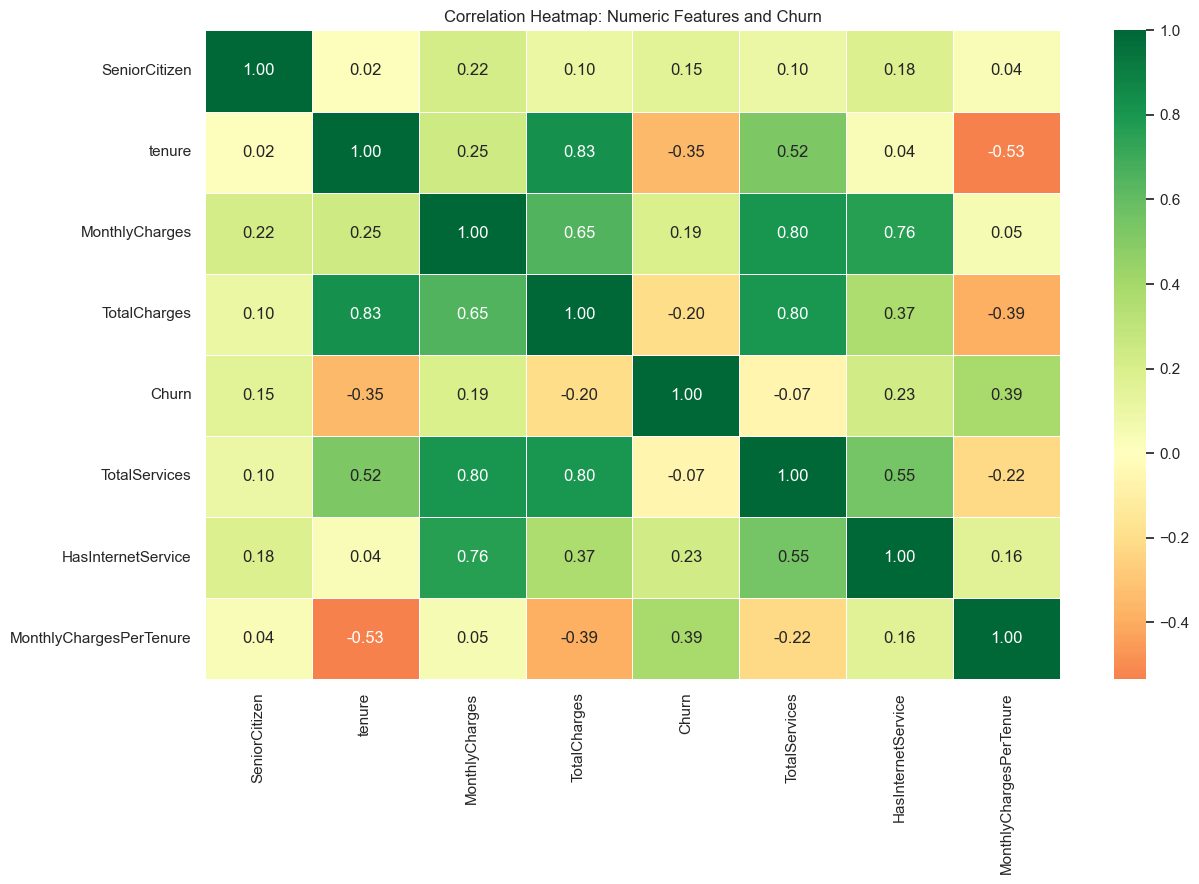

In [141]:
# 13. Numeric correlation matrix and heatmap
correlation_data = df.copy()
correlation_data["Churn"] = correlation_data["Churn"].map({"No": 0, "Yes": 1})
numeric_correlation = correlation_data.select_dtypes(include=np.number).corr()

plt.figure(figsize=(13, 9))
sns.heatmap(
    numeric_correlation,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    center=0,
    linewidths=0.5,
)
plt.title("Correlation Heatmap: Numeric Features and Churn")
plt.tight_layout()
plt.show()


Features most associated with Churn:
                         correlation_with_churn
MonthlyChargesPerTenure                  0.3861
tenure                                  -0.3522
HasInternetService                       0.2279
TotalCharges                            -0.1995
MonthlyCharges                           0.1934
SeniorCitizen                            0.1509
TotalServices                           -0.0673


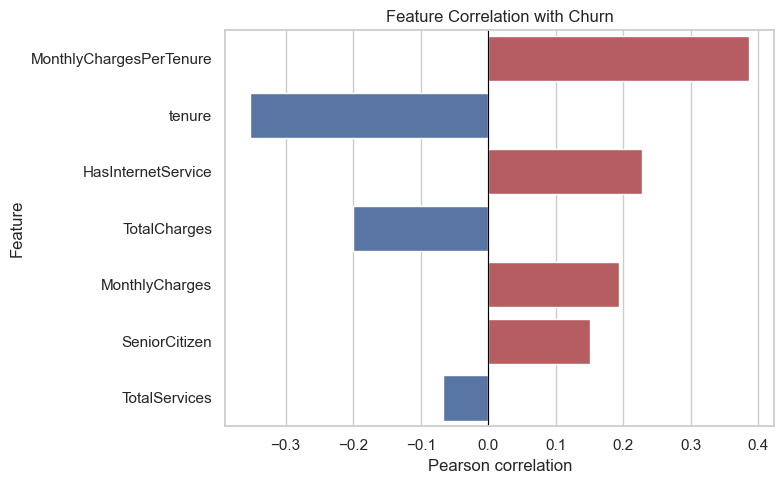

In [129]:
# 14. Correlation ranking against the churn target
churn_correlations = (
    numeric_correlation["Churn"]
    .drop("Churn")
    .sort_values(key=lambda values: values.abs(), ascending=False)
)
print("Features most associated with Churn:")
print(churn_correlations.to_frame("correlation_with_churn").round(4))

plt.figure(figsize=(8, 5))
sns.barplot(
    x=churn_correlations.values,
    y=churn_correlations.index,
    hue=churn_correlations.values > 0,
    palette={True: "#c44e52", False: "#4c72b0"},
    legend=False,
)
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Feature Correlation with Churn")
plt.xlabel("Pearson correlation")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


## 15. Train-test split theory

We split before fitting imputers, encoders, scalers, or the model. The training set teaches the transformations; the test set is held back as unseen data. `stratify=y` preserves the churn proportion in both sets, which is important because churn is the minority class.


In [6]:
# 16. Stratified train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE,
)

print(f"Training rows: {len(X_train):,}")
print(f"Testing rows: {len(X_test):,}")
print(f"Training churn rate: {y_train.mean():.3f}")
print(f"Testing churn rate: {y_test.mean():.3f}")


Training rows: 5,634
Testing rows: 1,409
Training churn rate: 0.265
Testing churn rate: 0.265


## 17. Handling target imbalance with SMOTE

The target contains many more non-churn customers than churn customers. A model can therefore achieve deceptively good accuracy by favoring the majority class.

**SMOTE (Synthetic Minority Over-sampling Technique)** creates synthetic minority-class observations using nearby minority samples. It is applied only to the training data. The test set must keep its original class distribution because it represents real-world performance.

The order used below is:

1. Impute, scale, and one-hot encode the training features.
2. Apply SMOTE only to the transformed training data.
3. Fit logistic regression on the balanced training data.
4. Evaluate on untouched test data.

SMOTE is inside an `imblearn` pipeline, so cross-validation also performs oversampling separately inside each training fold. We do not combine SMOTE with `class_weight="balanced"`; using both would compensate for the same imbalance twice.


In [7]:
# 18. Define leakage-safe preprocessing
# All imputers, encoders, and scalers are fitted only on training data.
numeric_features = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=np.number).columns.tolist()

numeric_preprocessor = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_preprocessor = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", drop="first")),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_preprocessor, numeric_features),
        ("categorical", categorical_preprocessor, categorical_features),
    ]
)

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)


Numeric features: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'TotalServices', 'HasInternetService', 'MonthlyChargesPerTenure']
Categorical features: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [17]:
# 19. Build and train the SMOTE logistic regression pipeline
# SMOTE runs after preprocessing and only during fit on training data.
logistic_pipeline = ImbPipeline(
    steps=[
        ("preprocessing", preprocessor),
        ("smote", SMOTE(random_state=RANDOM_STATE)),
        (
            "model",
            LogisticRegression(
                max_iter=2000,
                solver="liblinear",
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

logistic_pipeline.fit(X_train, y_train)

# Use a separate sampler only to display the before/after class counts.
X_train_transformed = logistic_pipeline.named_steps["preprocessing"].transform(X_train)
smote_check = SMOTE(random_state=RANDOM_STATE)
_, y_train_balanced = smote_check.fit_resample(X_train_transformed, y_train)

print("Original training distribution:")
print(y_train.value_counts().sort_index().rename(index={0: "No churn", 1: "Churn"}))
print("\nTraining distribution after SMOTE:")
print(pd.Series(y_train_balanced).value_counts().sort_index().rename(index={0: "No churn", 1: "Churn"}))
print("\nModel training completed.")


Original training distribution:
Churn
No churn    4139
Churn       1495
Name: count, dtype: int64

Training distribution after SMOTE:
Churn
No churn    4139
Churn       4139
Name: count, dtype: int64

Model training completed.


In [18]:
# 10. Generate test predictions
y_pred = logistic_pipeline.predict(X_test)
y_probability = logistic_pipeline.predict_proba(X_test)[:, 1]

print("First 10 predicted classes:", y_pred[:10])
print("First 10 churn probabilities:", np.round(y_probability[:10], 4))


First 10 predicted classes: [0 1 0 1 0 1 1 0 0 1]
First 10 churn probabilities: [0.1047 0.8408 0.1296 0.5589 0.0675 0.788  0.6565 0.3264 0.0098 0.5902]


In [10]:
# 11. Final test-set metrics
metrics = {
    "accuracy": accuracy_score(y_test, y_pred),
    "precision": precision_score(y_test, y_pred, zero_division=0),
    "recall": recall_score(y_test, y_pred, zero_division=0),
    "f1_score": f1_score(y_test, y_pred, zero_division=0),
    "roc_auc": roc_auc_score(y_test, y_probability),
    "average_precision_pr_auc": average_precision_score(y_test, y_probability),
}

metrics_table = pd.DataFrame(metrics.items(), columns=["Metric", "Value"])
metrics_table["Value"] = metrics_table["Value"].round(4)
print(metrics_table.to_string(index=False))
print("\nClassification report:")
print(classification_report(y_test, y_pred, target_names=["No churn", "Churn"], zero_division=0))


                  Metric  Value
                accuracy 0.7438
               precision 0.5113
                  recall 0.7834
                f1_score 0.6188
                 roc_auc 0.8470
average_precision_pr_auc 0.6696

Classification report:
              precision    recall  f1-score   support

    No churn       0.90      0.73      0.81      1035
       Churn       0.51      0.78      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.76      1409



                  Predicted: No churn  Predicted: Churn
Actual: No churn                  755               280
Actual: Churn                      81               293


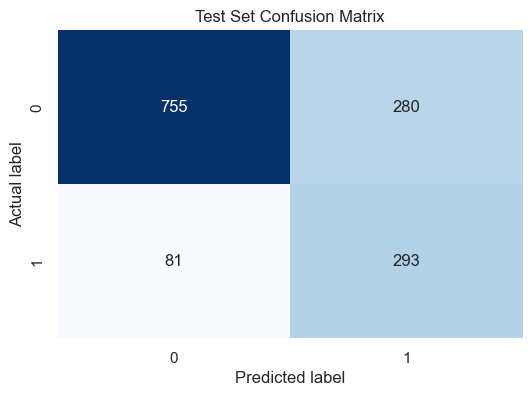

In [11]:
# 12. Confusion matrix and error analysis
cm = confusion_matrix(y_test, y_pred)
cm_table = pd.DataFrame(
    cm,
    index=["Actual: No churn", "Actual: Churn"],
    columns=["Predicted: No churn", "Predicted: Churn"],
)
print(cm_table)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Test Set Confusion Matrix")
plt.xlabel("Predicted label")
plt.ylabel("Actual label")
plt.show()


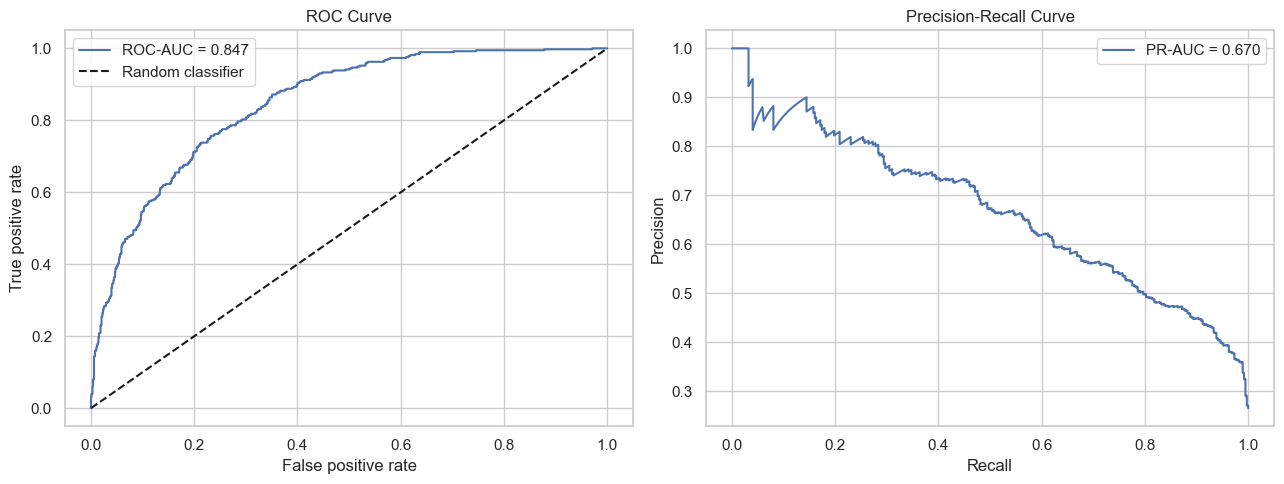

In [12]:
# 13. ROC and precision-recall curves
fpr, tpr, _ = roc_curve(y_test, y_probability)
precision_values, recall_values, _ = precision_recall_curve(y_test, y_probability)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(fpr, tpr, label=f"ROC-AUC = {metrics['roc_auc']:.3f}")
axes[0].plot([0, 1], [0, 1], "k--", label="Random classifier")
axes[0].set_title("ROC Curve")
axes[0].set_xlabel("False positive rate")
axes[0].set_ylabel("True positive rate")
axes[0].legend()

axes[1].plot(recall_values, precision_values, label=f"PR-AUC = {metrics['average_precision_pr_auc']:.3f}")
axes[1].set_title("Precision-Recall Curve")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend()

plt.tight_layout()
plt.show()


In [13]:
# 14. Stratified cross-validation on the training data
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
    "average_precision": "average_precision",
}

cv_results = cross_validate(
    logistic_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1,
)

cv_summary = pd.DataFrame(
    {
        metric: [cv_results[f"test_{metric}"].mean(), cv_results[f"test_{metric}"].std()]
        for metric in scoring
    },
    index=["mean", "std"],
).T.round(4)
print(cv_summary)


                     mean     std
accuracy           0.7593  0.0165
precision          0.5317  0.0218
recall             0.7826  0.0343
f1                 0.6331  0.0250
roc_auc            0.8478  0.0124
average_precision  0.6691  0.0229


In [14]:
# 15. Inspect model coefficients
feature_names = logistic_pipeline.named_steps["preprocessing"].get_feature_names_out()
coefficients = logistic_pipeline.named_steps["model"].coef_[0]
coefficient_table = pd.DataFrame(
    {"feature": feature_names, "coefficient": coefficients}
)
coefficient_table["absolute_coefficient"] = coefficient_table["coefficient"].abs()

print("Features increasing churn probability:")
print(
    coefficient_table.sort_values("coefficient", ascending=False)
    .head(10)[["feature", "coefficient"]]
    .to_string(index=False)
)
print("\nFeatures decreasing churn probability:")
print(
    coefficient_table.sort_values("coefficient", ascending=True)
    .head(10)[["feature", "coefficient"]]
    .to_string(index=False)
)


Features increasing churn probability:
                                    feature  coefficient
   categorical__InternetService_Fiber optic     1.114075
                      numeric__TotalCharges     0.478607
          categorical__PaperlessBilling_Yes     0.456635
           categorical__StreamingMovies_Yes     0.384520
           numeric__MonthlyChargesPerTenure     0.368236
categorical__PaymentMethod_Electronic check     0.363894
             categorical__MultipleLines_Yes     0.301164
               categorical__StreamingTV_Yes     0.274112
                     numeric__TotalServices     0.265982
                numeric__HasInternetService     0.070782

Features decreasing churn probability:
                                      feature  coefficient
               categorical__Contract_Two year    -1.800954
               categorical__Contract_One year    -0.869461
                              numeric__tenure    -0.866228
                      numeric__MonthlyCharges    -0.568482

In [19]:
# 16. Save the complete fitted pipeline as a PKL file
model_path = r"D:\AI_Training\telco_churn_logistic_regression.pkl"
joblib.dump(logistic_pipeline, model_path)
print(f"Saved model artifact: {model_path}")
print(f"File size: {os.path.getsize(model_path) / 1024:.2f} KB")


Saved model artifact: D:\AI_Training\telco_churn_logistic_regression.pkl
File size: 395.02 KB


In [20]:
# 17. Reload the PKL file and validate inference
loaded_pipeline = joblib.load(model_path)
reloaded_predictions = loaded_pipeline.predict(X_test)
reloaded_probabilities = loaded_pipeline.predict_proba(X_test)[:, 1]

print("Reloaded pipeline type:", type(loaded_pipeline).__name__)
print("Predictions identical after reload:", np.array_equal(y_pred, reloaded_predictions))
print(
    "Probabilities identical after reload:",
    np.allclose(y_probability, reloaded_probabilities),
)


Reloaded pipeline type: Pipeline
Predictions identical after reload: True
Probabilities identical after reload: True
